# Time Series Analysis: Nigeria CPI and Naira-USD Exchange Rate.

**Course:** NUTDTS816 - Time Series Analysis

**Series A:** Nigeria Consumer Price Index(All Items)

**Series B:** Naira-USD Exchange Rate

**Data Source:** NUTDTS816 Github Course Repository

# Purpose

This notebook explores, visualises and decomposes two monthly Nigerian economic time series before forecasting. Series A is the Nigeria Consumer Price Index(CPI), while Series B is the Naira-USD exchange rate. The analysis examines trend, seasonality, serial dependence, decomposition, transformation and seasonal adjustment, with particluar attention to features that may affect subsequent forecasting.

In [140]:
#Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Statistical/Time-series tools
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from pandas.plotting import lag_plot

#Display settings
pd.set_option("display.max_columns", None)

#plot style
plt.rcParams["figure.figsize"] = (9, 3.6)
plt.rcParams["axes.grid"] = True

In [91]:
#Raw GitHub URLs
CPI_URL = "https://raw.githubusercontent.com/toadesina/NUTDTS816_Course_Repository/main/data/nigeria_cpi.csv"

FX_URL = "https://raw.githubusercontent.com/toadesina/NUTDTS816_Course_Repository/main/data/nigeria_fx.csv"

In [92]:
#Load the Datasets
cpi_raw = pd.read_csv(CPI_URL)
fx_raw = pd.read_csv(FX_URL)

print("CPI shape:", cpi_raw.shape)
print("FX shape:", fx_raw.shape)

CPI shape: (144, 2)
FX shape: (139, 2)


In [93]:
#Data Inspection
print("CPI DATA")
display(cpi_raw.head())

print("\nFX DATA")
display(fx_raw.head())

print("CPI information")
cpi_raw.info()

print("\nFX information")
fx_raw.info()

print("CPI descriptive statistics")
display(cpi_raw.describe())

print("\nFX descriptive statistics")
display(fx_raw.describe())

print("CPI columns:",
cpi_raw.columns.tolist())
print("FX columns:", fx_raw.columns.tolist())

CPI DATA


,date,cpi
0,2014-01-01,20.1179
1,2014-02-01,20.2179
2,2014-03-01,20.3766
3,2014-04-01,20.5019
4,2014-05-01,20.6615



FX DATA


,date,ngn_usd
0,2015-01-01,167.5000
1,2015-02-01,178.1500
2,2015-03-01,196.5727
3,2015-04-01,196.5000
4,2015-05-01,196.5000


CPI information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    144 non-null    object 
 1   cpi     144 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.4+ KB

FX information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     139 non-null    object 
 1   ngn_usd  139 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.3+ KB
CPI descriptive statistics


,cpi
count,144.000000
mean,52.109399
std,31.250618
min,20.117900
25%,28.245175
50%,40.536050
75%,65.853225
max,131.166600



FX descriptive statistics


,ngn_usd
count,139.000000
mean,602.831804
std,485.869077
min,167.500000
25%,305.366500
50%,379.500000
75%,765.718400
max,1670.276400


CPI columns: ['date', 'cpi']
FX columns: ['date', 'ngn_usd']


# Task 1: Loading and Tidying the Series

In [94]:
#Convert date columns to datetime
cpi_raw["date"] = pd.to_datetime(cpi_raw["date"])
fx_raw["date"] = pd.to_datetime(fx_raw["date"])

#Check the resulting data types
print(cpi_raw.dtypes)
print()
print(fx_raw.dtypes)

date    datetime64[ns]
cpi            float64
dtype: object

date       datetime64[ns]
ngn_usd           float64
dtype: object


In [95]:
#Check Chronological ordering
print("CPI dates sorted:", cpi_raw["date"].is_monotonic_increasing)
print("FX dates sorted:", fx_raw["date"].is_monotonic_increasing)

cpi_raw = cpi_raw.sort_values("date")
fx_raw = fx_raw.sort_values("date")

CPI dates sorted: True
FX dates sorted: True


In [96]:
#Checking Duplicate Timestamps
print("CPI duplicate timestamps:", cpi_raw["date"].duplicated().sum())
print("FX duplicate timestamps:", fx_raw["date"].duplicated().sum())

CPI duplicate timestamps: 0
FX duplicate timestamps: 0


No duplicated timestamps were detected in either series; therefore, no observations were removed on the basis of timestamp duplication.

In [97]:
#Creating the datetime index
cpi = cpi_raw.set_index("date").copy()

fx = fx_raw.set_index("date").copy()

cpi.head()

fx.head()

,ngn_usd
date,
2015-01-01,167.5000
2015-02-01,178.1500
2015-03-01,196.5727
2015-04-01,196.5000
2015-05-01,196.5000


In [98]:
#Setting the frequency
cpi = cpi.asfreq("MS")
fx = fx.asfreq("MS")

print("CPI frequency:", cpi.index.freq)
print("FX frequency:", fx.index.freq)

CPI frequency: <MonthBegin>
FX frequency: <MonthBegin>


In [99]:
#Checking for missing timestamps
cpi_missing_dates = pd.date_range(start=cpi.index.min(), end=cpi.index.max(), freq="MS").difference(cpi.index)

fx_missing_dates = pd.date_range(start=fx.index.min(), end=fx.index.max(), freq="MS").difference(fx.index)

print("Missing CPI timestamps:")
print(cpi_missing_dates)

print("\nMissing FX timestamps:")
print(fx_missing_dates)

Missing CPI timestamps:
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

Missing FX timestamps:
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [100]:
#Checking for missing values
print("Missing CPI values:")
print(cpi.isna().sum())

print("\nMissing FX values:")
print(fx.isna().sum())

Missing CPI values:
cpi    0
dtype: int64

Missing FX values:
ngn_usd    0
dtype: int64


In [101]:
#Summary Table
tidy_summary = pd.DataFrame({"Series": ["Nigeria CPI", "Nigeria FX"],
                             "Start": [cpi.index.min(), fx.index.min()],
                             "End": [cpi.index.max(), fx.index.max()],
                             "Observations": [len(cpi), len(fx)],
                             "Frequency": [cpi.index.freqstr, fx.index.freqstr],
                             "Duplicate timestamps": [cpi.index.duplicated().sum(), fx.index.duplicated().sum()],
                             "Missing values": [cpi.isna().sum().iloc[0], fx.isna().sum().iloc[0]]})

display(tidy_summary)

,Series,Start,End,Observations,Frequency,Duplicate timestamps,Missing values
0,Nigeria CPI,2014-01-01,2025-12-01,144,MS,0,0
1,Nigeria FX,2015-01-01,2026-07-01,139,MS,0,0


# Task 2: Visual Exploration.
This section examines the time-series structure of the Nigerian CPI and Naira-USD exchange rate using Time plots, Seasonal plots, Seasonal subseries plots and Lag plots.

In [102]:
#Extract the individual times series.
cpi_series = cpi["cpi"]
fx_series = fx["ngn_usd"]

print("CPI:")
display(cpi_series.head())

print("\nNigeria FX:")
display(fx_series.head())

CPI:


,cpi
date,
2014-01-01,20.1179
2014-02-01,20.2179
2014-03-01,20.3766
2014-04-01,20.5019
2014-05-01,20.6615



Nigeria FX:


,ngn_usd
date,
2015-01-01,167.5000
2015-02-01,178.1500
2015-03-01,196.5727
2015-04-01,196.5000
2015-05-01,196.5000


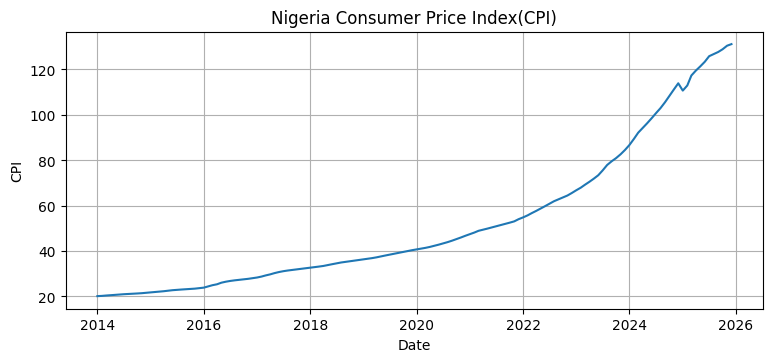

In [103]:
#Time plot: Nigeria CPI
plt.figure(figsize=(9, 3.6))
plt.plot(cpi_series.index, cpi_series.values)
plt.title("Nigeria Consumer Price Index(CPI)")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.grid(True)
plt.show()

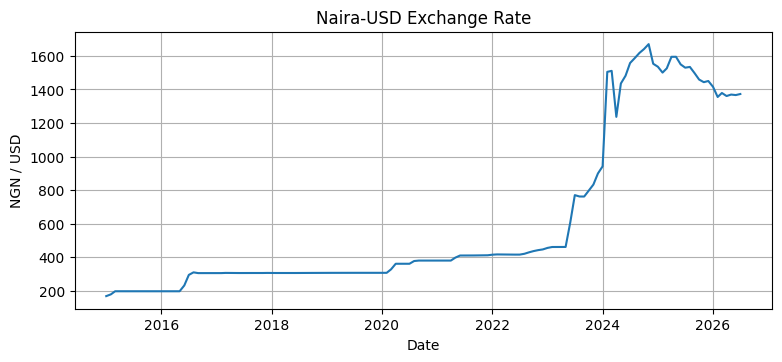

In [104]:
#Time plot: Naira-USD Exchange Rate

plt.figure(figsize=(9, 3.6))
plt.plot(fx_series.index, fx_series.values)
plt.title("Naira-USD Exchange Rate")
plt.xlabel("Date")
plt.ylabel("NGN / USD")
plt.grid(True)
plt.show()

In [105]:
#Seasonal plots
def seasonal_plot(series, title, ylabel):
  temp = pd.DataFrame({"value": series})
  temp["year"] = temp.index.year
  temp["month"] = temp.index.month

  plt.figure(figsize=(9, 3.6))

  for year, group in temp.groupby("year"):
    plt.plot(group["month"], group["value"], marker="o", alpha=0.6, label=str(year))

  plt.xticks(range(1, 13),
             ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

  plt.title(title)
  plt.xlabel("Month")
  plt.ylabel(ylabel)
  plt.grid(True)
  plt.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
  plt.tight_layout()
  plt.show()

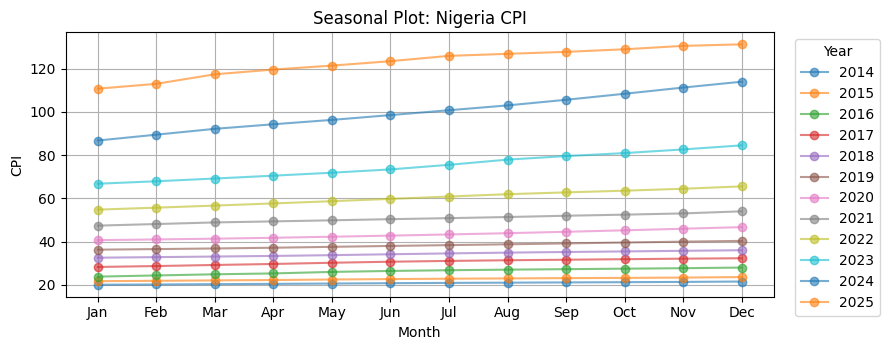

In [106]:
seasonal_plot(cpi_series, "Seasonal Plot: Nigeria CPI", "CPI")

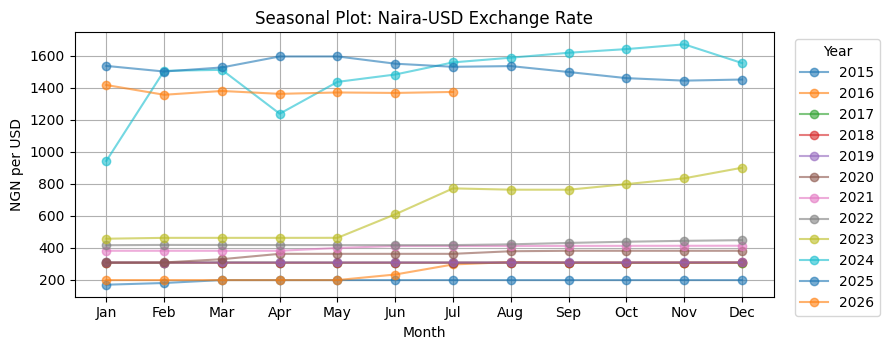

In [107]:
seasonal_plot(fx_series, "Seasonal Plot: Naira-USD Exchange Rate", "NGN per USD")

In [154]:
#Seasonal Subseries Plots
def seasonal_subseries_plot(series, title, ylabel):
  temp = pd.DataFrame({"value": series})
  temp["year"] = temp.index.year
  temp["month"] = temp.index.month

  months = range(1, 13)
  month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

  fig, axes = plt.subplots(3, 4, figsize=(10, 5), sharey=False)
  axes = axes.flatten()

  for month, ax in zip(months, axes):
    data = temp[temp["month"] == month]

    ax.plot(data["year"], data["value"], marker="o", color='#B8860B', lw=1.2)
  ax.axhline(data["value"].mean(), linestyle="--", alpha=0.7)

  ax.set_title(month_names[month - 1])
  ax.set_xlabel("Year")
  ax.set_ylabel(ylabel)
  ax.grid(True)

  fig.suptitle(title, fontsize=16)
  plt.tight_layout()
  plt.show()

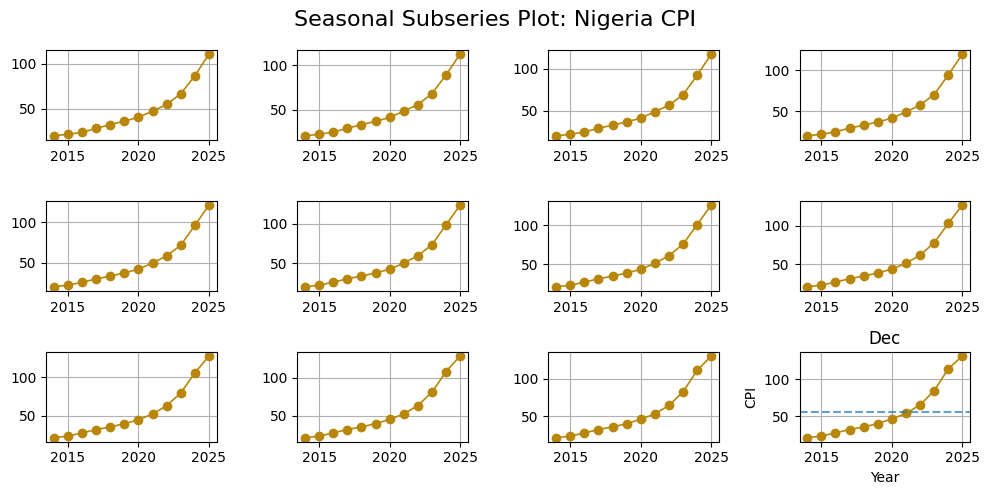

In [155]:
seasonal_subseries_plot(cpi_series, "Seasonal Subseries Plot: Nigeria CPI", "CPI")

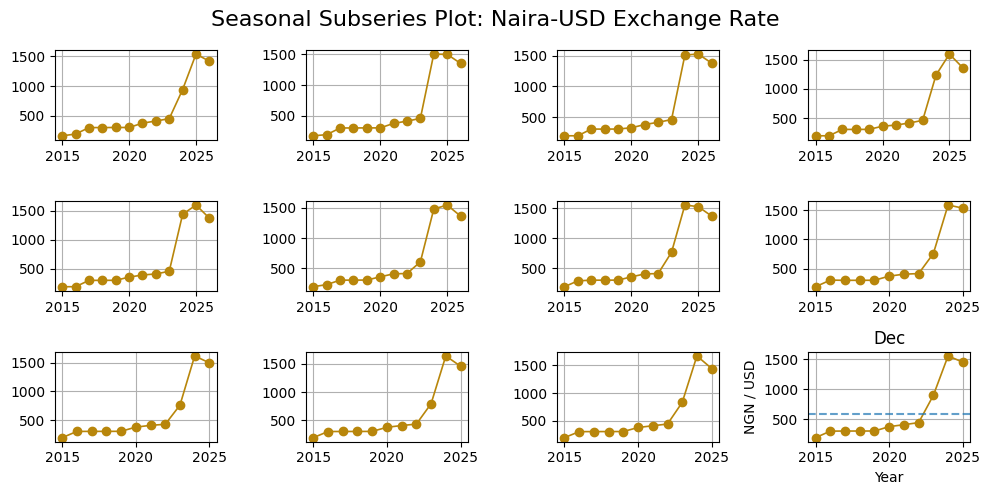

In [156]:
seasonal_subseries_plot(fx_series, "Seasonal Subseries Plot: Naira-USD Exchange Rate", "NGN / USD")

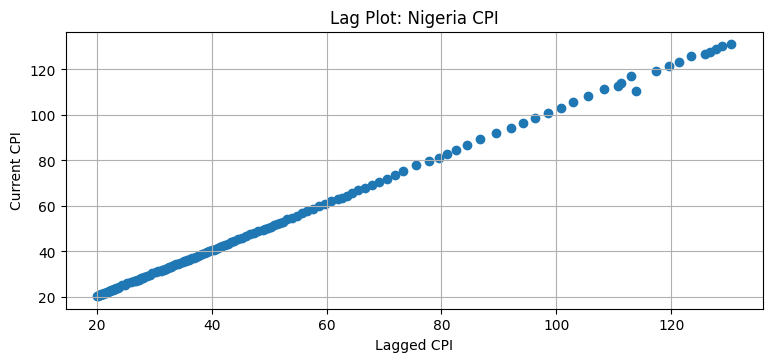

In [111]:
#Lag plot: Nigeria CPI

plt.figure(figsize=(9, 3.6))
lag_plot(cpi_series)
plt.title("Lag Plot: Nigeria CPI")
plt.xlabel("Lagged CPI")
plt.ylabel("Current CPI")
plt.grid(True)
plt.show()

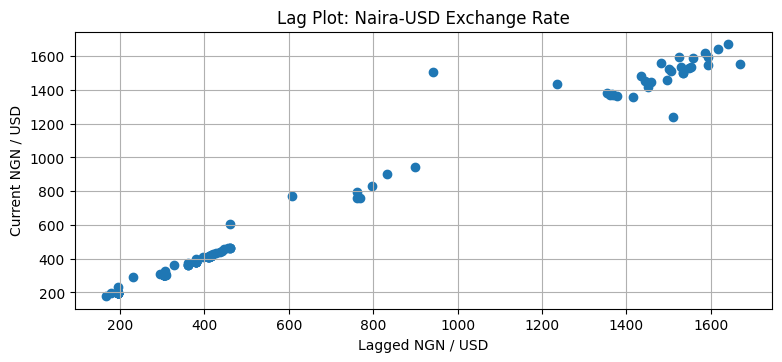

In [112]:
#Lag plot: Naira-USD Exchange Rate

plt.figure(figsize=(9, 3.6))
lag_plot(fx_series)
plt.title("Lag Plot: Naira-USD Exchange Rate")
plt.xlabel("Lagged NGN / USD")
plt.ylabel("Current NGN / USD")
plt.grid(True)
plt.show()

### Task 2: Exploratory Visual Analysis and Interpretation.
**Overall Time-Series Trends**

##### Series A: Nigeria Consumer Price Index(CPI)

The Nigeria CPI series exhibits a strong and persistent upward trend throughout the observation period, indicating clear non-stationarity in the mean. From approximately 2014 to 2019, the series increases relatively gradually. From around 2020 onward, the upward movement becomes more pronounced, producing an increasingly steep trajectory through 2024 and 2025.

The increasing slope suggests that the absolute change in the CPI becomes larger as the level of the series rises. this behavior indicates that the series is dominated by a long-term trend rather than fluctuations around a stable mean.

A notable level change is also visible around the transition into 2025. This movement should be considered when interpreting the later-period trend.

Therefore, the CPI is strongly trend-dominated and does not appear stationary in its original level form. The magnitude of changes also appears to increase with the level of the series, which will be investigated further when considering transformations and decomposition.

####Series B: Naira-USD Exchange Rate
The Naira-USD exchange rate series displays substantial non-stationarity and several changes in its level and variability over time.
The earlier portion of the series exhibits relatively lower exchange-rate levels compared with the later period, although it is not completely stable. From 2023 onward, there is a pronounced upward shift in the exchange-rate level, accompanied by increased variability. The series subsequently reaches substantially higher levels than those observed during the earlier part of the sample.

This behavior is consistent with a change in the underlying exchange-rate regime. In particular, the Central Bank of Nigeria introduced a willing-buyer/willing-seller framework and unified the foreign exchange market on June 14, 2023. The CBN's own economic report attributed the depreciation partly to the adoption of a more market-driven exchange-rate regime.

Therefore, the Nigeria-USD exchange rate series is non-stationary and exhibits evidence of level shifts and charging variability. These characteristics will need to be considered when analysing its autocorrelation, transformation and decomposition.

###  Seasonal Plots

##### Series A: Nigeria CPI
This seasonal plot shows that the dominant feature of the CPI is its strong upward movement across years. Successive yearly trajectories tend to be positioned at progressively higher levels.
Although there are month-to-month movement within interval years, there is no immediately dominant and visually stable repeating monthly pattern comparable in magnitude to the long term trend. The relatively similar shapes of the yearly trajectories suggest that the long-term upward movement is substantially stronger than any apparent within-year seasonal effect.

Therefore, the seasonal plot provides preliminary evidence that trend dominantes seasonality in the CPI. the presence and strength of any formal seasonal component will be assessed further using the seasonal subseries plot, the ACF and decomposition.

##### Section B: Naira-USD Exchange Rate
The seasonal plot of the Naira-USD exchange rate series is dominated by changes in the level and regime of the series rather than a stable recurring monthly pattern.
Earlier years occupy stantially lower levels, whereas the trajectories from 2023 onward are positioned considerably higher. The seperation between these periods makes it difficult to identify a consistent month-specific pattern across the entire sample.
Consequently, the seasonal plot provides little visual evidence of a strong, stable annual seasonal pattern. Instead, structural changes and changing levels appear to be more important features of the series.

#### Seasonal Subseries Plots
##### Series A: Nigeria CPI
The seasonal subseries plots show a consistent upward movement across the years within most, if not all, carlender months. The increase is therefore not concentrated in one particular month but occurs across the carlender year.
The similarity of the upward trajectories across the monthly subseries suggests that the principal feature of the CPI is its long-term trend, while any month-specific seasonal effect appears relatively small in comparison.
However, this does not prove that seasonality is absent. A relatively weak seasonal component can still exist beneath a dominant trend. Its magnitude will therefore be quantified using the ACF and decomposition methods in ssubsquent tasks.

##### Series B: Naira-USD Exhange Rate
The Exchange rate seasonal subseries plots reveal substantial changes in the level of the exchange rate across the sample. The monthly subseries show broadly similar timing of the major upward movement Soccuring in the later part pof the sample.

The synchronization of the major level shift across months provides further evidence that the dominant feature is a change in the underlying regime rather than a recurring monthly seasonal pattern.
Thus, the subseries plots suggest that structural changes in the exchange rate environment are considerably more prominent than any stable annual seasonal pattern.

## Lag Plots
##### Series A: Nigeria CPI

The CPI lag plot displays a very strong positive linear relationship between the current CPI value and its previous month-month value. The observations are concentrated closely around an upward-sloping diagonal.
This indicates a strong lag-1 dependence, meaning that consecutive CPI observations are highly related. However, the strong relationship is expected partly because the original CPI series contains a pronounced trend.
Therefore, the lag plot should not by itself be interpreted as evidence of deterministic behavior or as proof of a random-walk process. Formal autocorrelation analysis using the ACF and analysis of the first-differenced series will provide a more appropriate assessment of the dependence structure.

##### Series B: Naira-USD Exchange Rate
The exchange-rate lag plot differs substantially from the CPI lag plot. Rather than forming one continous narrow diagonal pattern, the observations apear in distinct clusters corresponding to different exchange-rate levels.
This clustering a consistent with the presence of different regimes of substianlly different echange-rate levels. The increased dispersion of higher exchange-rate levels also suggests that the variability of the series may change with its level.
The lag plot therefore provides visual evidence of strong serial dependence combined with possible structural changes and heteroskedasticity. however, the existence and agnitude of autocorrelation will be examined more formally using the ACF.

### Conclusion
Overall, both series are clearly non-stationary in their original levels, but they exhibit different forms of non-stationarity. The Nigeria CPI is primarily characterised by a persistent and accelerating upward trend, with relatively weaker visual evidence of seasonal variation. The Naira-USD exchange rate is characterised by pronounced changes in level and variability, particularly from 2023 onward, with structural changes appearing more prominent than a stable recurring seasonal pattern. Both series exhibit strong dependence between consecutive observations, as indicated by their lag plots. However, the lag plots alone cannot distinguish trend-induced dependence from other forms of serial correlation. Therefore, the next stage of the analysis will use ACF and first differences to examine the dependence structure and assess how differencing affects the apparent non-stationarity.

## Task 3: Autocorrelation Analysis

The autocorrelation function (ACF) is used to examine how to examine the dependence between observations at different lags. The ACF is first examined for each original series and then for its first difference to assess whether differencing reduces the serial dependence associated with the non-stationary level series.

In [113]:
#First Difference

cpi_diff = cpi_series.diff().dropna()
fx_diff = fx_series.diff().dropna()

print("CPI first difference:")
display(cpi_diff.head())

print("\nFX first difference:")
display(fx_diff.head())

CPI first difference:


,cpi
date,
2014-02-01,0.1000
2014-03-01,0.1587
2014-04-01,0.1253
2014-05-01,0.1596
2014-06-01,0.1599



FX first difference:


,ngn_usd
date,
2015-02-01,10.6500
2015-03-01,18.4227
2015-04-01,-0.0727
2015-05-01,0.0000
2015-06-01,-0.0841


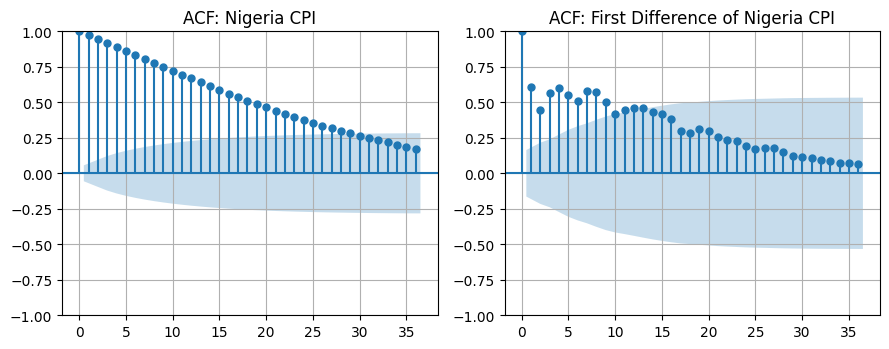

In [114]:
#ACF of Original and first-differenced CPI
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

plot_acf(cpi_series.dropna(), lags=36, ax=axes[0], alpha=0.5)
axes[0].set_title("ACF: Nigeria CPI")
plot_acf(cpi_diff, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title("ACF: First Difference of Nigeria CPI")

plt.tight_layout()
plt.show()

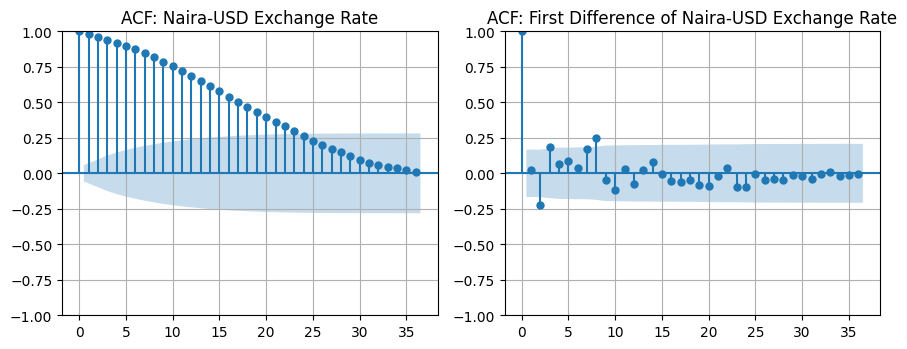

In [115]:
#ACF of Original and first-differenced Naira-USD Exchange Rate

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
plot_acf(fx_series.dropna(), lags=36, ax=axes[0], alpha=0.5)
axes[0].set_title("ACF: Naira-USD Exchange Rate")
plot_acf(fx_diff, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title("ACF: First Difference of Naira-USD Exchange Rate")

plt.tight_layout()
plt.show()


### ACF of Nigeria CPI - Original Series
the ACF of the original Nigeria CPI series remains strongly positive and slowly decays across the examined lags. A large number of autocorrelation coefficients lie outside the 95% confidence bounds.
This slow decay is characteristic of a strongly trended or otherwise non-stationary series. In a stationary series, autocorrelations generally decay relatively quickly, whereas persistent positive autocorrelation across many lags is commonly observed when a series contains trend.
The result is consistent with the time plot and lag point above, which showed a persistent upward movement and strong dependence between consecutive observations.
### Interpretation
Th original CPI series is not suitable for analysis as a stationary level series. Differencing is therefore appropriate for further investigation.

### ACF of First-Differenced Nigeria CPI
After first differencng, the ACF changes substantially. The very strong long-range autocorrelation observed in the original CPI is substantially reduced, but several positive autocorrelations remain statistically significant, particularly at the shorter lags.
This indicates that first differencing has substantially reduced the trend-related dependence, but the resulting series still contains serial correlation. therefore, first differencing has not produced an ACF that resembles pure white noise.
However, this does not by itself establish that a second difference is required. A slowly decaying ACF after first differencing can arise from remaining non-stationarity, autoregressive structure or other dependence in the differenced process. Further diagnostics are therefore required before selecting the order of differencing. standard guidance specifically cautions against applying more differences than necessary because over differencing can introduce artificial dynamics.
### Interpretation:
First differencing substantially improves the CPI series but does not eliminate all serial dependence. the stationarity of the first-differenced CPI should therefore be assessed further before deciding whether an additional difference is warranted.

### ACF of Naira-USD Exchange Rate - Original Series
The ACF of the original Naira-USD exchange rate series displays a strong positive autocorrelation that declines slowly across the lags examined.
This is consistent with the pronounced non-stationarity observed in the time plot. The persistent autocorrelation that declines slowly across the lags examined.
This is consistent with the pronounced non-stationarty observed in the time plot. The persistent autocorrelation reflects the fact that exchange-rate levels remain strongly related to their preceding levels, particularly during periods in which the series moves within relatively persistent regimes.
The ACF therefore provides additional evidence that the original exchange-rate level series should not be treated as stationary.
However, the ACF alone cannot distinguish between a unit-root process, deterministic trend and structural-break effects. Given the substantial level changes observed in the time plot, the latter are particularly important considerations.
### Interpretation: The original exchange-rate series exhibits strong persistence and non-stationarity, motivating examination of its first differences.

### ACF of First-Differenced Naira-USD Exchange Rate
The first-differenced exchange-rate series displays a dramatic reduction in autocorrelation.Apart from a relatively small negative spike at lag 1, the remaining autocorrelations are within the approximate 95% confidence bounds.
This indicates that first differencing has removed most of the persistent dependence present in the original exchange-rate levels. The resulting series therefore has characteristics that are substantially closer to a stationary process.
The remaining significant lag-1 negative autocorrelation should not be immediately interpreted as proof of an MA(1) process. It indicates some short-term serial dependence, but model identification would require additional diagnostics, particularly the PACF and, eventually, model estimationand residual diagnostics.
It is also more precise to say that the differenced exchange-rate series is approximately uncorrelated beyond lag 1 rather than simply calling it white noise. A white noise conclusion is stronger and should ideally be supported by a formal test such as the Ljung-Box test.
### Interpretation
Overall, the ACf analysis confirms substantial persistence and non-stationarity in both original series. the Nigeria CPI exhibits a slowly decaying positive ACF, consistent with its strong upward trend. First diffeencing substantially reduces this dependence,although statistically significant autocorrelation remains at several short lags. The naira-USD exchange rate similarly exhibits a slow decaying ACF in levels, while its first difference shows a much more rapid reduction in autocorrelation, with only limited evidence of short-term dependence. These results indicate that differencing is an important step toward obtaining stationary representations of both series, but the appropriate order of differencing should be determined using additional diagnostics rather than the ACF alone.

## Task 4: Additive versus Multiplicative Structure
This section assesses whether an additive or multiplicative representation is more appropriate for each time series. The assessment is based on the relationship between the level of each series and the magnitude of its fluctuations, together with visual inspection of the time-series behaviour.
An additive structure assumes that the magnitude of the seasonal and irregular components remains approximately constant across different levels of the series:
- \(**Y_t** = **T_t** + **S_t** + **R_t**\).

A multiplicative structure assumes that the magnitude of these components varies proportionally with the level of the series:       
- \(**Y_t** = **T_t** x **S_t** x **R_t**\)

The analysis therefore examines whether variability increases as the level of each series increases.

In [116]:
#Rolling Mean and Rolling Standard Deviation

window = 12

cpi_rolling_mean = cpi_series.rolling(window).mean()
cpi_rolling_std = cpi_series.rolling(window).std()

fx_rolling_mean = fx_series.rolling(window).mean()
fx_rolling_std = fx_series.rolling(window).std()

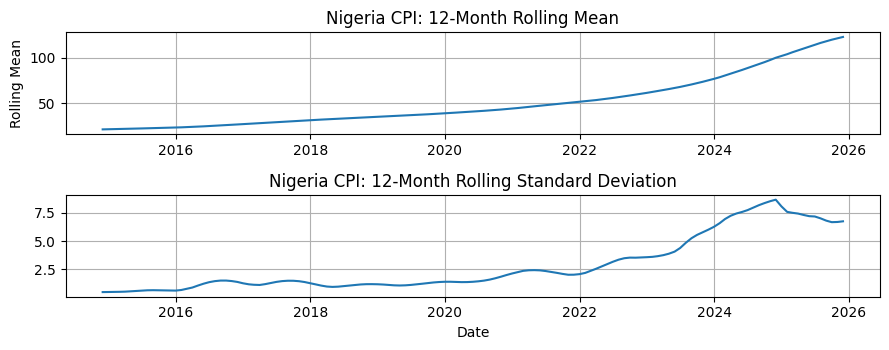

In [117]:
#CPI: Rolling Mean and Rolling Standard Deviation

fig, axes = plt.subplots(2, 1, figsize=(9, 3.6))

axes[0].plot(cpi_series.index, cpi_rolling_mean)
axes[0].set_title("Nigeria CPI: 12-Month Rolling Mean")
axes[0].set_ylabel("Rolling Mean")
axes[0].grid(True)

axes[1].plot(cpi_series.index, cpi_rolling_std)
axes[1].set_title("Nigeria CPI: 12-Month Rolling Standard Deviation")
axes[1].set_xlabel("Date")
axes[1].grid(True)

plt.tight_layout()
plt.show()

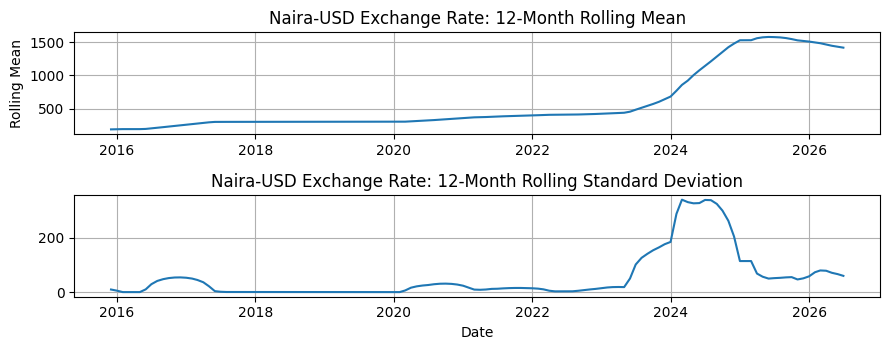

In [118]:
#NGN-USD Exchange Rate: Rolling Mean and Rolling Standard Deviation.
fig, axes = plt.subplots(2, 1, figsize=(9, 3.6))
axes[0].plot(fx_series.index, fx_rolling_mean)
axes[0].set_title("Naira-USD Exchange Rate: 12-Month Rolling Mean")
axes[0].set_ylabel("Rolling Mean")
axes[0].grid(True)

axes[1].plot(fx_series.index, fx_rolling_std)
axes[1].set_title("Naira-USD Exchange Rate: 12-Month Rolling Standard Deviation")
axes[1].set_xlabel("Date")
axes[1].grid(True)

plt.tight_layout()
plt.show()

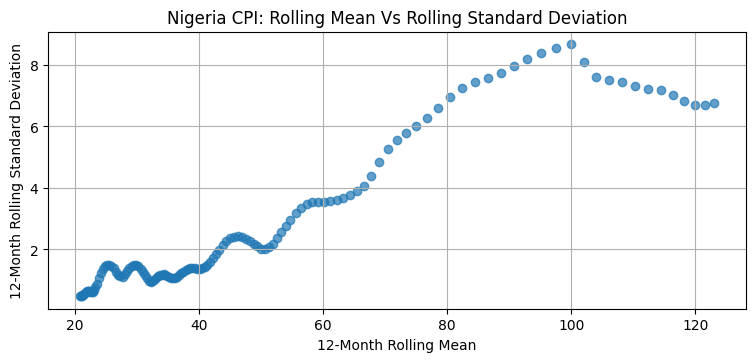

In [119]:
#CPI: Rolling Mean versus Rolling Standard Deviation

plt.figure(figsize=(9, 3.6))
plt.scatter(cpi_rolling_mean.dropna(), cpi_rolling_std.dropna(), alpha=0.7)

plt.title("Nigeria CPI: Rolling Mean Vs Rolling Standard Deviation")
plt.xlabel("12-Month Rolling Mean")
plt.ylabel("12-Month Rolling Standard Deviation")
plt.grid(True)
plt.show()

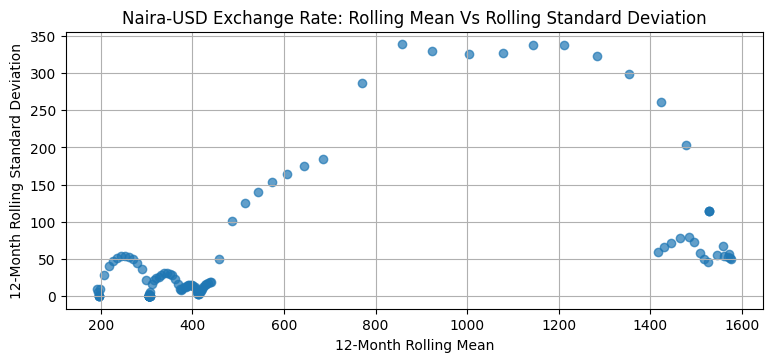

In [120]:
#NGN-USD Exchange Rate: Rolling Mean vs Rolling Standard Deviation
plt.figure(figsize=(9, 3.6))

plt.scatter(fx_rolling_mean.dropna(), fx_rolling_std.dropna(), alpha=0.7)
plt.title("Naira-USD Exchange Rate: Rolling Mean Vs Rolling Standard Deviation")
plt.xlabel("12-Month Rolling Mean")
plt.ylabel("12-Month Rolling Standard Deviation")
plt.grid(True)
plt.show()

In [121]:
#Compare CPI level and variability across periods
cpi_periods = pd.DataFrame({"CPI": cpi_series})
cpi_periods["Period"] = pd.cut(cpi_periods.index.year, bins=[2013, 2017, 2021, 2025], labels=["2014-2017", "2018-2021", "2022-2025"])

cpi_summary = cpi_periods.groupby("Period", observed=True)["CPI"].agg(["mean", "std"])

cpi_summary["CV"] = cpi_summary["std"] / cpi_summary["mean"]

display(cpi_summary)

,mean,std,CV
Period,,,
2014-2017,25.123369,3.906089,0.155476
2018-2021,41.638967,6.379046,0.153199
2022-2025,89.565862,25.037389,0.279542


In [122]:
#Compare Exchange Rate level and variability across periods
fx_periods = pd.DataFrame({"NGN-USD": fx_series})
fx_periods["Period"] = pd.cut(fx_periods.index.year, bins=[2014, 2018, 2022, 2026], labels=["2015-2018", "2019-2022", "2023-2026"])

fx_summary = fx_periods.groupby("Period", observed=True)["NGN-USD"].agg(["mean", "std"])

fx_summary["CV"] = fx_summary["std"] / fx_summary["mean"]

display(fx_summary)

,mean,std,CV
Period,,,
2015-2018,264.104058,53.968299,0.204345
2019-2022,371.252710,47.747831,0.128613
2023-2026,1239.453391,403.100019,0.325224


In [123]:
#Log Transformation for diagnostic comparison

log_cpi = np.log(cpi_series)
log_fx = np.log(fx_series)

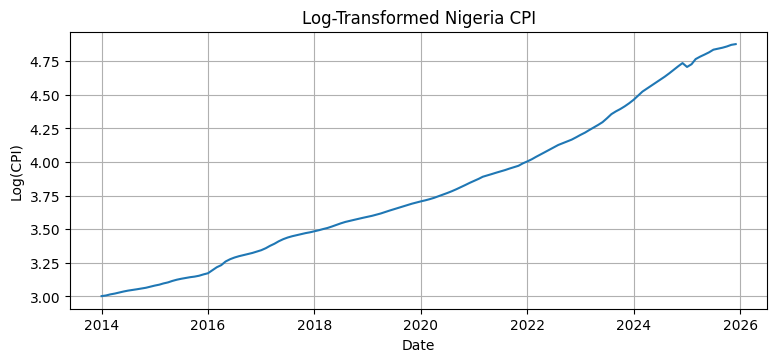

In [124]:
#Log-transformed CPI
plt.figure(figsize=(9, 3.6))
plt.plot(log_cpi.index, log_cpi)
plt.title("Log-Transformed Nigeria CPI")
plt.xlabel("Date")
plt.ylabel("Log(CPI)")
plt.grid(True)
plt.show()

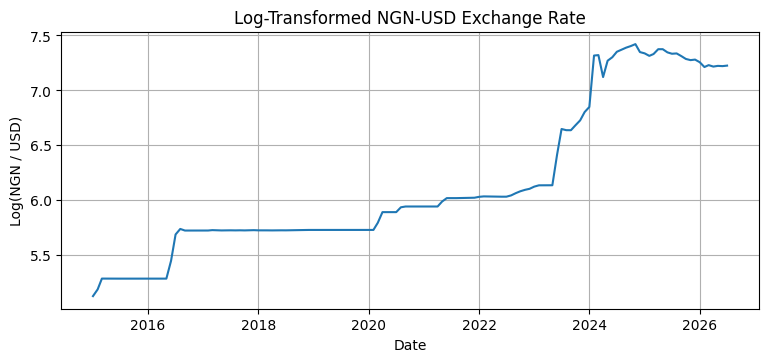

In [125]:
#Log-transformed NGN-USD
plt.figure(figsize=(9, 3.6))
plt.plot(log_fx.index, log_fx)
plt.title("Log-Transformed NGN-USD Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Log(NGN / USD)")
plt.grid(True)
plt.show()

## Additive vs Multiplicative Structure
The rolling statistics indicate that both series exhibit substantial changes in their level and variability over time.
### Nigeria CPI:
The 12-month rolling mean shows a persistent upward trend, while the rolling standard deviation increases considerably from around 2022 onward. The rolling-mean standard deviation plot also shows a positive, nonlinear relationship between the level of CPI and its variability. This suggests that fluctuations increase as the level of the series rises, providing evidence more consistent with a multiplicative-type structure than a simple additive structure.
### Naira-USD Exchange Rate:
The rolling mean shows a pronounced upward shift from 2023, accompanied by a substantial increase in rolling standard deviation. The mean-standard deviation plot forms didtinct clusters, indicating different levels and volatility regimes rather than a stable level-variance relationship. This makes a simple additiv representation less appropriate, while a multiplicative/logarithmic representation may be useful for modelling proportional changes. However, the structural change remains an important feature that transformation alone may not remove.
The period-level statistics support these observations. For CPI, the coefficient of variation increases from approximately 0.15 in the earlier periods to 0.28 during 2022-2025. For the exchange rate, it increases from 0.13 during 2019-2022 to 0.33 during 2023-2026. Thus, relative variability also increased in the later periods.
The logarithmic plots further suggests that a log transformation is useful for subsequent analysis. It substantially reduces the curvature of the CPI series and compresses the scale of the exchange-rate series, although the exchange-rate structural shift remains vivible.
### Conclusion:
The diagnostics provide stronger evidence for a multiplicative-type structure, particularly for CPI, while the exchange-rate requires additional consideration of structural changes. The eventual decomposition results and transformation diagnostics will be used to make the final decision.

## Task 5:  Classical and STL Decomposition.
Decomposition seperates a time series into its underlying components: trend-cycle, seasonal and remainder.
Two decomposition approaches are applied.
1. Classical decomposition, which uses a Moving-Average procedure to estimate the trend-cycle.
2. STL(Seasonal-Trend decomposition using Loess), which uses locally weighted regression to estimate the trend and seasonal components.
Both methods are applied using a 12-month seasonal period because the series are monthly and a yearly seasonal cycle is therefore the natural seasonal frequency.
The decomposition will be compared to determine whether the two methods identify similar underlying patterns and whether the seasonal component is substantial relative to the trend and remainder.

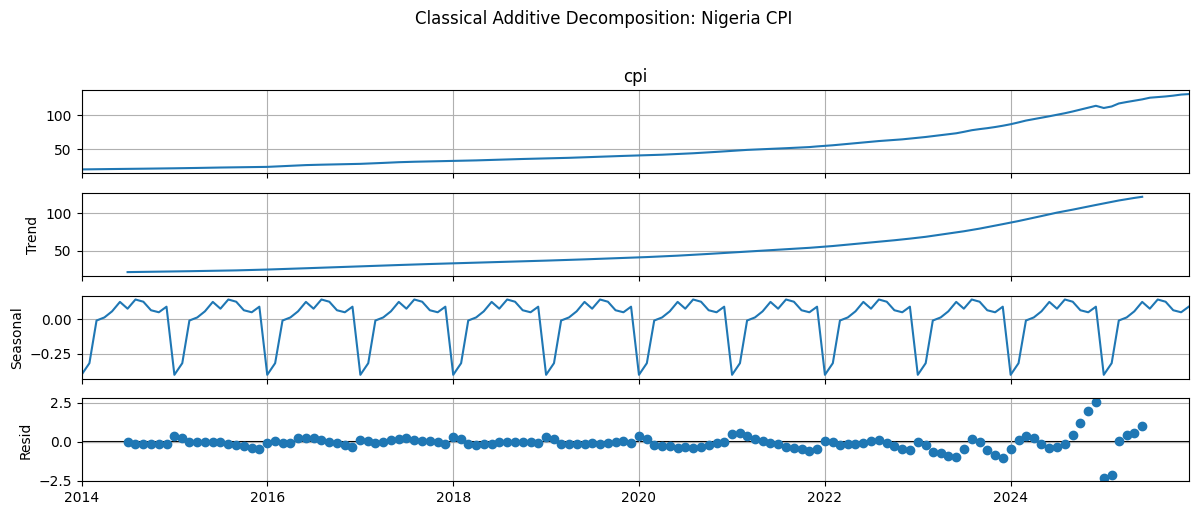

In [126]:
#Classical Decomposition of Nigeria CPI
cpi_classical = seasonal_decompose(cpi_series, model="additive", period=12)
cpi_classical.plot()
plt.suptitle("Classical Additive Decomposition: Nigeria CPI", y=1.02)
plt.tight_layout()
plt.show()

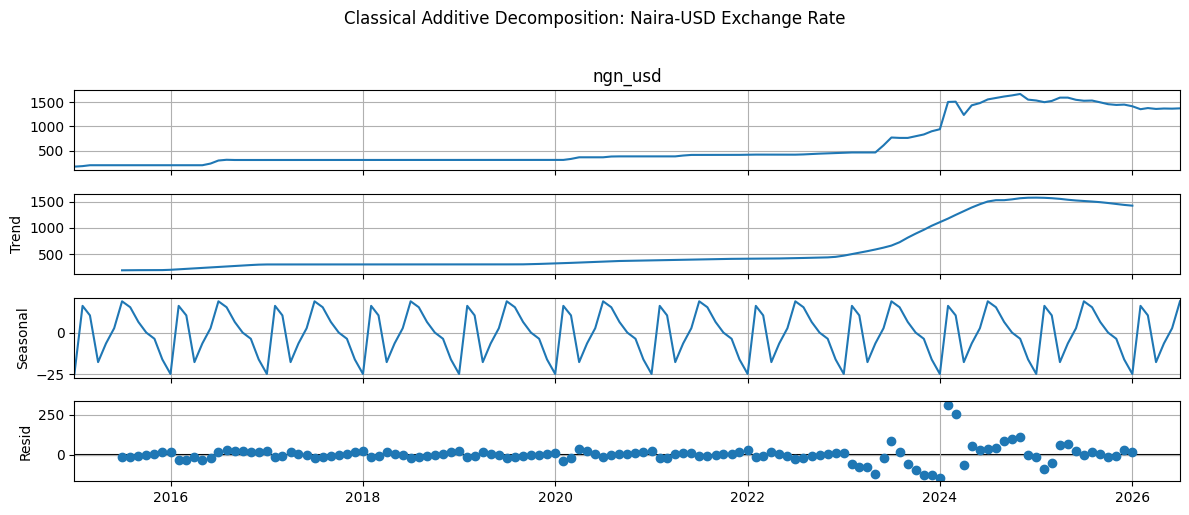

In [127]:
#Classical Decomposition of Naira-USD exchange rate.
fx_classical = seasonal_decompose(fx_series, model="additive", period=12)
fx_classical.plot()
plt.suptitle("Classical Additive Decomposition: Naira-USD Exchange Rate", y=1.02)
plt.tight_layout()
plt.show()

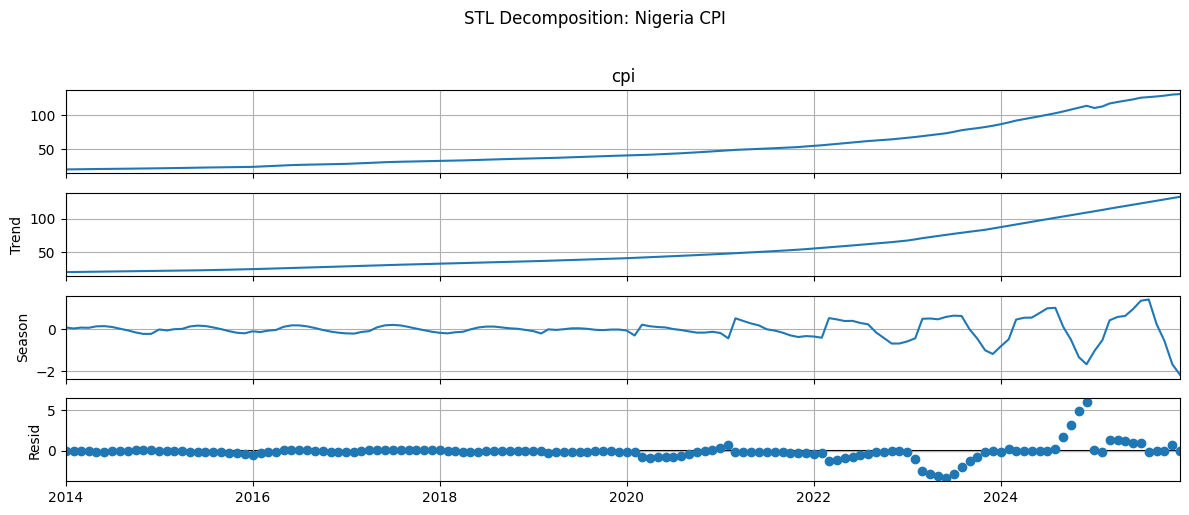

In [128]:
#STL Decomposition of Nigeria CPI
cpi_stl = STL(cpi_series, period=12, robust=True).fit()

cpi_stl.plot()
plt.suptitle("STL Decomposition: Nigeria CPI", y=1.02)
plt.tight_layout()
plt.show()

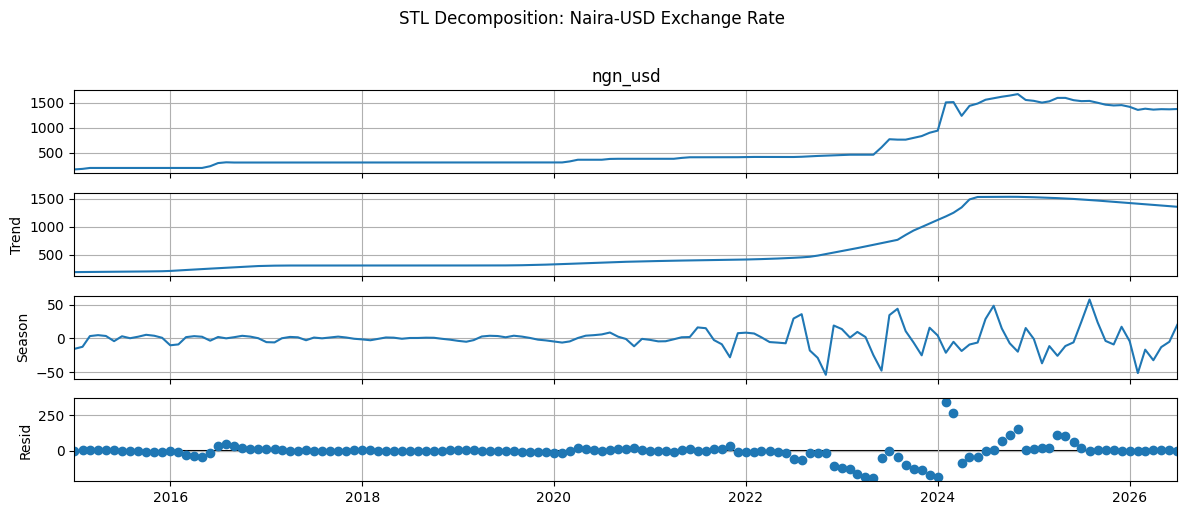

In [129]:
#STL Decomposition of Naira-USD Exchange Rate
fx_stl = STL(fx_series, period=12, robust=True).fit()

fx_stl.plot()
plt.suptitle("STL Decomposition: Naira-USD Exchange Rate", y=1.02)
plt.tight_layout()
plt.show()

## Task 5: Classical  and STL Decomposition.
Classical additive and STL decompositions were applied using a 12-month seasonal period to seperate each series into trend-cycle, seasonal and remainder components.
### Nigeria CPI
Both decompositions identify a strong and persistent upward trend, with the increase becoming more pronounced in the later part of the sample. The classical decomposition shows a recurring seasonal pattern, although its magnitude is small relative to the overall trend.
STL provides a more flexible seasonal estimate and suggests that the seasonal effect somewhat changes over time. The remainder becomes more volatile, particularly around 2023-2024, indicating that large movements are not fully explained by the estimated trend and seasonal components.
Overall, **trend is the dorminant feature of the CPI series, with weaker but changing seasonality and larger irregular movements in the later period.**

### Naira-USD Exchange Rate
Both decompositions identify a relatively stable earlier trend followed by a pronounced upward shift around 2023 and a subsequent higher-level regime. the large remainder around this period indicates that the abrupt change is not fully captured by the smooth trend and seasonal components.
The classical decomposition estimates a recurring seasonal pattern, while STL allows the seasonal component to vary over time. However, given the major structural change, the apparent seasonality should be interpreted cautiously.
Overall, **structural change and changing variability are more prominent features of the exchange-rate series than a stable seasonal pattern.**
### Comparison
The two methods produce broadly similar trend estimates, but STL provides greater flexibility in representing changes in seasonality over time. Both decompositions highlight substantial irregular movements around the 2023-2024 period, particularly for the exchange rate.

In [157]:
#Log Transformation

log_cpi = np.log(cpi_series)
log_fx = np.log(fx_series)

display(log_cpi.head())
display(log_fx.head())

,cpi
date,
2014-01-01,3.001610
2014-02-01,3.006568
2014-03-01,3.014387
2014-04-01,3.020518
2014-05-01,3.028272


,ngn_usd
date,
2015-01-01,5.120983
2015-02-01,5.182626
2015-03-01,5.281032
2015-04-01,5.280662
2015-05-01,5.280662


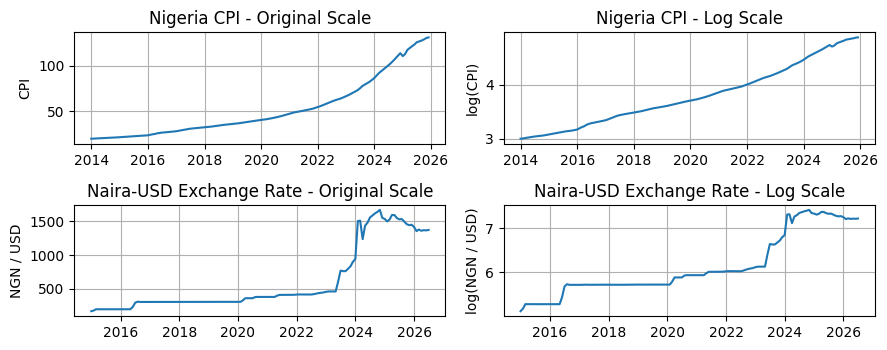

In [131]:
#Original versus Log-Transformed Series

fig, axes = plt.subplots(2, 2, figsize=(9, 3.6))

#Original CPI
axes[0, 0].plot(cpi_series)
axes[0, 0].set_title("Nigeria CPI - Original Scale")
axes[0, 0].set_ylabel("CPI")

#CPI - Log
axes[0, 1].plot(log_cpi)
axes[0, 1].set_title("Nigeria CPI - Log Scale")
axes[0, 1].set_ylabel("log(CPI)")

#Original Naira-USD Exchange Rate
axes[1, 0].plot(fx_series)
axes[1, 0].set_title("Naira-USD Exchange Rate - Original Scale")
axes[1, 0].set_ylabel("NGN / USD")

#NGN-USD - Log
axes[1, 1].plot(log_fx)
axes[1, 1].set_title("Naira-USD Exchange Rate - Log Scale")
axes[1, 1].set_ylabel("log(NGN / USD)")

plt.tight_layout()
plt.show()

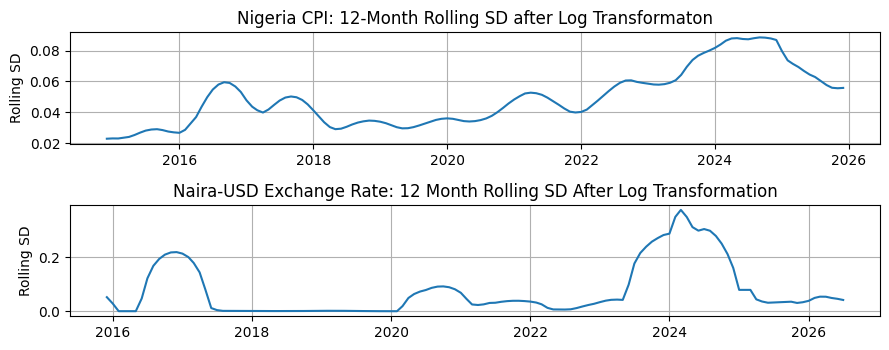

In [132]:
#Rolling Standard Deviation after Log Transformation.

log_cpi_rolling_std = log_cpi.rolling(12).std()
log_fx_rolling_std = log_fx.rolling(12).std()

fig, axes = plt.subplots(2, 1, figsize=(9, 3.6))

axes[0].plot(log_cpi_rolling_std)
axes[0].set_title("Nigeria CPI: 12-Month Rolling SD after Log Transformaton")
axes[0].set_ylabel("Rolling SD")

axes[1].plot(log_fx_rolling_std)
axes[1].set_title("Naira-USD Exchange Rate: 12 Month Rolling SD After Log Transformation")
axes[1].set_ylabel("Rolling SD")

plt.tight_layout()
plt.show()

In [133]:
from scipy.stats import boxcox
#Box-Cox Lambda Estimates

cpi_boxcox, cpi_lambda = boxcox(cpi_series)
fx_boxcox, fx_lambda = boxcox(fx_series)

print(f"CPI Box-Cox lambda: {cpi_lambda:.3f}")
print(f"FX Box-Cox lambda: {fx_lambda:.3f}")

CPI Box-Cox lambda: -0.429
FX Box-Cox lambda: -0.682


### Task 6: Log/Box-Cox Transformation.

The log and Box-Cox transformations were examined to determine whether a variance-stabilising transformation would provide a more appropriate representation of the two series.
### Nigeria CPI
On the original scale, the CPI exhibits strong upward curvature and increasing variability as the level rises. After applying the natural logarithm, the series becomes substantially more linear and the scale of the later fluctuations is compressed.
The 12-month rolling standard deviation of log(CPI) is also  considerably smaller than that of the original series, although it continue to vary over time. Therefore, the logarithmic transformation substantially reduces the level-dependent variability but does not completely eliminate time-varying volatility.
### Naira-USD Exchange Rate
The logarithmic transformation substantially compresses the large difference between the earlier and later exchange-rate levels. However, the pronounced change in level around 2023 remains visible after transformation. This indicates that the log transformation improves the scale of the series but does not remove the structural change.
### Box-Cox Results
The estimated Box-Cox parameters are:

**CPI: λ = -0.429**

**NGN-USD: λ = -0.682**

Both estimates are below zero, indicating that the data may benefit from a transformation stronger than a simple logarithm for variance stabilisation. However, the estimates should be interpreted cautiously because both series contain substantial trend changes, unusual movements and possible structural changes.
### Conclusion
The diagnostics support the use of a **logarithmic transformation as a practical variance-stabilising transformation**, particularly for the CPI. The transformation substantially reduces curvature and the dependence of variability on the level of the series, although time-varying volatility remains.
For the exchange rate, the log transformation improves the scale but does not eliminate the pronounced structural change around 2023. The Box-Cox estimates suggests that stronger transformation may be possible, but the final transformation choice should consider the decomposition results and subsequent stationarity diagnostics rather than relying on **λ** alone.

### Task 7: Seasonally Adjusted Series
The seasonal component identified during decomposition is removed from each series to obtain seasonally adjusted values.
The purpose is to examine the underlying trend and other non-seasonal movements without the influence of the estimated recurring seasonal pattern.
The STL decomposition is used for seasonal adjustment because it provides a flexible estimate of seasonality that can vary over time.


In [134]:
#Seasonally adjusted series using STL decomposition.
cpi_sa = cpi_series - cpi_stl.seasonal
fx_sa = fx_series - fx_stl.seasonal

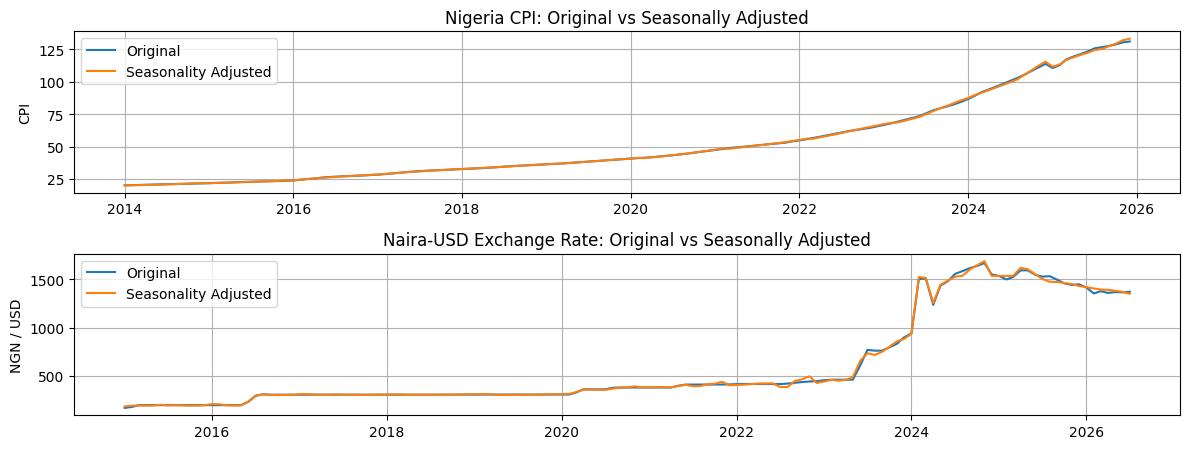

In [135]:
#Original vs seasonally adjusted series.
fig, axes = plt.subplots(2, 1, figsize=(12, 4.6))

#CPI
axes[0].plot(cpi_series, label="Original")
axes[0].plot(cpi_sa, label="Seasonality Adjusted")
axes[0].set_title("Nigeria CPI: Original vs Seasonally Adjusted")
axes[0].set_ylabel("CPI")
axes[0].legend()

#NGN-USD Exchange rate
axes[1].plot(fx_series, label="Original")
axes[1].plot(fx_sa, label="Seasonality Adjusted")
axes[1].set_title("Naira-USD Exchange Rate: Original vs Seasonally Adjusted")
axes[1].set_ylabel("NGN / USD")
axes[1].legend()

plt.tight_layout()
plt.show()

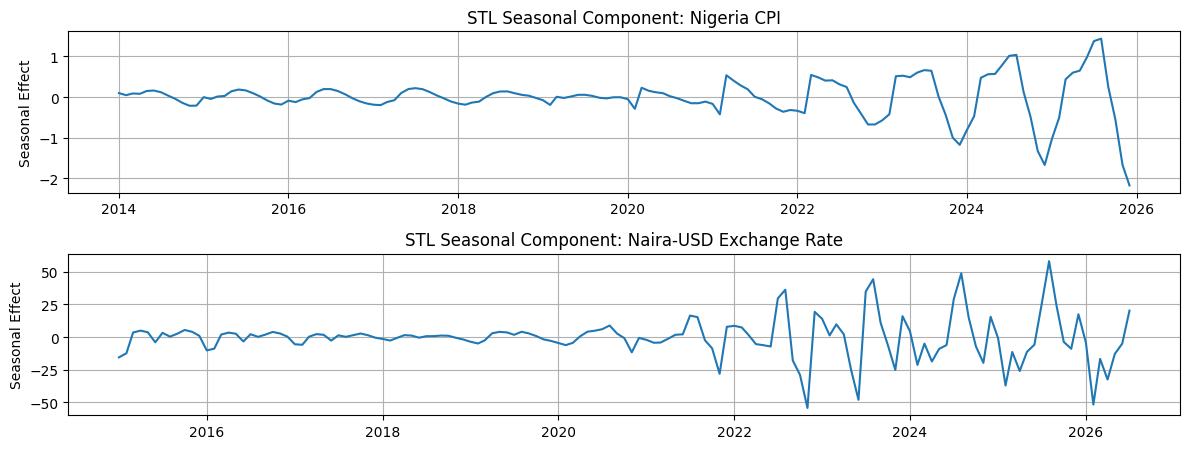

In [136]:
#Seperating the Seasonal Component
fig, axes = plt.subplots(2, 1, figsize=(12, 4.6))

axes[0].plot(cpi_stl.seasonal)
axes[0].set_title("STL Seasonal Component: Nigeria CPI")
axes[0].set_ylabel("Seasonal Effect")

axes[1].plot(fx_stl.seasonal)
axes[1].set_title("STL Seasonal Component: Naira-USD Exchange Rate")
axes[1].set_ylabel("Seasonal Effect")

plt.tight_layout()
plt.show()

## Task 7: Seasonally Adjusted Series
The STL seasonal components and the resulting seasonally adjusted series were examined to assess the contribution of recurring annual effects.
### Nigeria CPI
The STL seasonal component shows relatively small fluctuations during the earlier part of the sample, followed by larger seasonal movements from approximately 2021-2022 onward. This indicates that the magnitude of the estimated seasonal effect changes over time.
Despite this increase, the original and seasonally adjusted CPI series are closely aligned. This indicates that **seasonality is a relatively small component of the overall CPI variation, with the long-term trend remaining dominant**.
### NGN-USD Exchange Rate
The STL seasonal component is relatively small during the earlier period but becomes considerably more variable after 2022. This suggests that the seasonal component is not constant throughout the sample.
The original and seasonally adjusted exchange-rate series remain closely aligned overall, although the adjustment produces more visible smoothing during the later high-volatility period. The major upward shift around 2023 remains present after seasonal adjustment, confirming that **the structural change is not primarily a seasonal effect**.
### Conclusion
Seasonal adjustment removes the estimated recurring component while retaining the major trend and structural movements in both series. For CPI, the adjustment has relatively little effect because trend dominates the series. For the exchange rate, the adjustment produces greater smoothing in the later period, but the 2023 structural change remains clearly visible.
**The STL decomposition identifies seasonal components in both series, but their measured strength is weak relative to the remainder**. The changing seasonal amplitude also supports further consideration when developing the final modelling approach.


## Task 8: Strength of Trend and Seasonality
The strength of trend and seasonality will be quantified from the STL decomposition to compare the relative contribution of these components to the variation in each series.

In [137]:
def decomposition_strength(stl_result):
    """Calculate strength of trend and seasonality from an STL decomposition"""

    components = pd.concat([stl_result.trend, stl_result.seasonal, stl_result.resid], axis=1).dropna()
    trend = components.iloc[:, 0]
    seasonal = components.iloc[:, 1]
    remainder = components.iloc[:, 2]

    trend_strength = max(0, 1 - np.var(remainder, ddof=1) / np.var(trend + remainder, ddof=1))
    seasonal_strength = max(0, 1 - np.var(remainder, ddof=1) / np.var(seasonal + remainder, ddof=1))

    return trend_strength, seasonal_strength

# Calculate strength for CPI
cpi_trend_strength, cpi_seasonal_strength = decomposition_strength(cpi_stl)

# Calculate strength for FX
fx_trend_strength, fx_seasonal_strength = decomposition_strength(fx_stl)

# Create Comparison Table
strength_df = pd.DataFrame({"Series": ["Nigeria CPI", "Naira-USD Exchange Rate"],
                            "Strength of Trend": [cpi_trend_strength, fx_trend_strength],
                            "Strength of Seasonality": [cpi_seasonal_strength, fx_seasonal_strength]})

display(strength_df.round(3))

,Series,Strength of Trend,Strength of Seasonality
0,Nigeria CPI,0.999,0
1,Naira-USD Exchange Rate,0.983,0


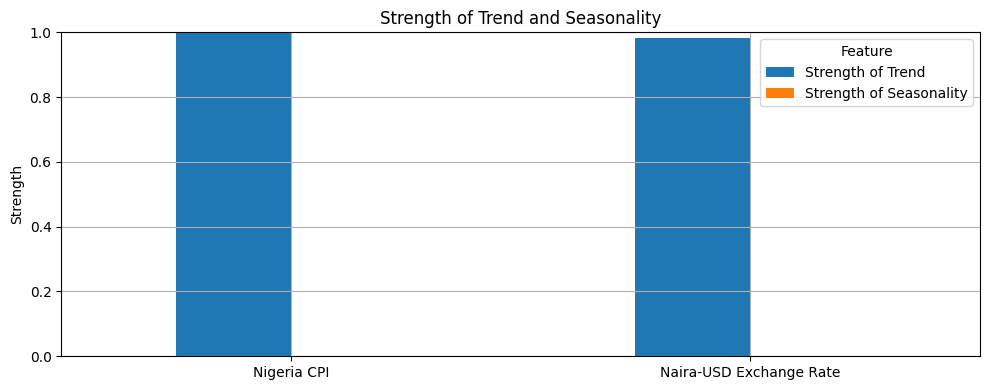

In [139]:
strength_df.set_index("Series").plot(kind="bar", figsize=(10, 4))

plt.title("Strength of Trend and Seasonality")
plt.ylabel("Strength")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.tight_layout()
plt.show()

## Task 8: Strength of Trend and Seasonality
The STL-based strength measures provide quantitative support for the patterns observed in the earlier decomposition plots.
For Nigeria CPI, the strength of the trend is **0.999**, indicating an extremely strong trend relative to the remainder component. The strength of seasonality is **0.000**, indicating that the seasonal component contributes relatively little systematic variation compared with the remainder.
For the Naira-USD exchange rate, the strength of trend is **0.983**, also indicating a very strong trend component. The strength of seasonality is **0.000**, suggesting weak seasonal structure relative to the remainder.
Overall, both series are dominated by trend and structural movements, while seasonality is comparatively weak according to the STL strength measures. The exchange-rate result should be interpreted alongside the pronounced structural change observed around 2023.

## Task 9: Narrative

The findings from Task 1-8 are synthesised into manager-focused narratives describing the main characteristics of each series, the presence of regular and non-regular patterns, notable structural changes and implications for forecasting.

## Nigeria CPI: Narrative.
**What the series is doing.**

Nigeria CPI shows a persistent and accelerating upward trend throughout 2014-2025. The increase becomes more pronounced in the later years, accompanied by greater variability.

**Regular Patterns**

The STL decomposition identifies recurring seasonal movements. However, the strength-of-seasonality measure is **0.000**, while the strength-of-trend measure is **0.999**. This indicates that trend dominates the series and that seasonality is relatively weak compared with the remainder.

**Non-regular Movements and Structural Features**

The later period contains larger irregular movements and increasing variability. These features are not fully explained by the smooth trend and seasonal components, indicating that unusual movements should be considered when interpreting the series.

**Forecasting Considerations**

The strong persistence and non-stationarity observed in the original series indicate that forecasting should not be performed directly on the raw CPI levels without appropriate transformation and perhaps, differencing. The analysis also suggests that variance stabilisation may be useful, particularly because the logarithmic transformation reduced curvature and level-dependent variability. Future forecasting should account for the strong trend and changing variability, while treating seasonality as a comparatively secondary component.

### Naira-USD Exchange Rate: Narrative
**What the Series is doing**

The Naira-USD exchange rate exhibits substantial persistence, changing levels and increasing variability over 2015-2026. A pronounced upward shift occurs around 2023, followed by a higher-level regime.

**Regular Patterns.**

Although the STL decomposition identifies a seasonal component, the strength-of-seasonality measure is **0.000**, compared with a strength of strength measure of **0.983**. This indicates that the dominant systematic feature is the trend/level movement rather than stable recurring seasonality.

**Non-regular Movements and Structural Features.**

The major level shift around 2023 represents an important structural feature. The associated large remainder indicates that the movement is not fully captured by the smooth trend and seasonal componentss. Volatility also changes considerably across the sample.

**Forecasting Considerations.**

The original exchange-rate series should not be treated as a stable stationary process. Transformation and differencing may help reduce persistence and level-dependent variability. However, they will not necessatily remove structural changes. Forecasting models should therefore be assessed for their ability to accomodate changing regimes and volatility, particularly around major level shifts.

## Conclusion
The analysis shows that both Nigeria CPI and the Naira-USD exchange rate are strongly non-stationary in their original levels and are dominated by persistent trend and structural movements rather than strong recurring seasonality.

Nigeria CPI exhibits sustained and accelerating growth, accompanied by increasing variability at higher levels. The logarithmic transformation substantially reduces curvature and level-dependent variability, making it a suitable transformation for subsequent modelling.

The Naira-USD exchange rate exhibits strong persistence, changing levels and substantially higher variability in the later period, with a pronounced structural shift around 2023. Although logarithmic transformation improves the scale of the sries, it does not remove this structural change.

The STL strength measures provide quantitative support for these findings, with trend strenghts of **0.999 for CPI** and **0.983 for the exchange rate**, while both series have a seasonal strength of **0.000**. These results indicate that trend and structural movements are considerably more prominent than seasonal variation.

Overall, the findings indicate that neither series should be modelled directly in its original level form without further consideration of transformation, differencing and structural changes. These characteristics should guide the selection and evaluation of forecasting models in subsequent analysis.